<a href="https://www.kaggle.com/code/ehsanghoreshi/boom-bust-rebuild-the-2008-shock-and-the-ames-h?scriptVersionId=346586143" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Boom, Bust, Rebuild: How the 2008 Shock Reshaped the Ames Housing Market

**A structural-break analysis and price model for the Ames, Iowa housing market (2006–2010)**

This notebook extends a policy-shock lens — the same lens used in *Berlin Real Estate: Policy-Shock Analysis & Price* — to the most consequential housing shock in modern U.S. history: the 2008 financial crisis.

Most public notebooks on this dataset stop at "predict `SalePrice`." This one asks a sharper question first:

> **Did the crisis only lower prices, or did it change the *rules* the market prices by** — i.e. did the dollar value of an extra square foot, or of a quality point, shift once the shock hit?

**Roadmap**

1. Load & clean the data
2. Define the shock window (Lehman Brothers, September 2008) and explore the market around it
3. Test for a structural break in the price–area and price–quality relationships (statistics, not just charts)
4. Engineer features and build a price-prediction pipeline (Linear/Ridge/Lasso → Random Forest → XGBoost)
5. Interpret the winning model (permutation importance + SHAP) and connect it back to the shock analysis
6. Conclusions, limitations, and a concrete next step (merging in mortgage-rate data)

**Data**: the Ames, Iowa housing dataset (De Cock, 2011) — 2,930 residential sales, 2006–2010, 82 features. This is the dataset behind Kaggle's classic *House Prices – Advanced Regression Techniques* competition, in its fuller original form.


## 1. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
pd.set_option("display.max_columns", 60)


## 2. Load the data

On Kaggle: open **Notebook settings → Internet → On** (one toggle, no dataset attachment needed) and run top to bottom. If a matching dataset is already attached under `/kaggle/input/`, the loader will find it automatically instead of downloading.

In [2]:
def load_ames_data():
    '''Load the Ames Housing dataset: prefer a locally-attached Kaggle dataset,
    fall back to downloading the canonical copy (Rdatasets mirror of De Cock's data).'''
    local_candidates = []
    input_root = "/kaggle/input"
    if os.path.isdir(input_root):
        for dirpath, _, filenames in os.walk(input_root):
            for f in filenames:
                if f.lower() in ("ames.csv", "ameshousing.csv", "ames_housing_data.csv"):
                    local_candidates.append(os.path.join(dirpath, f))

    if local_candidates:
        path = local_candidates[0]
        print(f"Loaded local dataset: {path}")
        return pd.read_csv(path)

    url = ("https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/"
           "master/csv/openintro/ames.csv")
    print(f"No local dataset found -- downloading from:\n{url}")
    df = pd.read_csv(url)
    os.makedirs("data", exist_ok=True)
    df.to_csv("data/ames_raw.csv", index=False)
    return df

df_raw = load_ames_data()
print(df_raw.shape)
df_raw.head()


No local dataset found -- downloading from:
https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/openintro/ames.csv
(2930, 83)


,rownames,Order,PID,area,price,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,Alley,Lot.Shape,Land.Contour,Utilities,Lot.Config,Land.Slope,Neighborhood,Condition.1,Condition.2,Bldg.Type,House.Style,Overall.Qual,Overall.Cond,Year.Built,Year.Remod.Add,Roof.Style,Roof.Matl,Exterior.1st,Exterior.2nd,Mas.Vnr.Type,...,Half.Bath,Bedroom.AbvGr,Kitchen.AbvGr,Kitchen.Qual,TotRms.AbvGrd,Functional,Fireplaces,Fireplace.Qu,Garage.Type,Garage.Yr.Blt,Garage.Finish,Garage.Cars,Garage.Area,Garage.Qual,Garage.Cond,Paved.Drive,Wood.Deck.SF,Open.Porch.SF,Enclosed.Porch,X3Ssn.Porch,Screen.Porch,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition
0,1,1,526301100,1656,215000,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,...,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,2,2,526350040,896,105000,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,...,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,3,3,526351010,1329,172000,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,...,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,4,4,526353030,2110,244000,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,...,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,5,5,527105010,1629,189900,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,...,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


## 3. Clean & prepare

This dataset has a well-documented quirk: for many categorical features, a missing value doesn't mean *unknown* — it means the house genuinely doesn't have that feature (no pool, no alley access, no fireplace...). We encode those as an explicit `"None"` category rather than imputing or dropping them.

In [3]:
df = df_raw.copy()
df.columns = [c.replace(".", "_") for c in df.columns]

# Columns where NaN means "does not have this feature"
none_means_absent = [
    "Alley", "Bsmt_Qual", "Bsmt_Cond", "Bsmt_Exposure", "BsmtFin_Type_1",
    "BsmtFin_Type_2", "Fireplace_Qu", "Garage_Type", "Garage_Finish",
    "Garage_Qual", "Garage_Cond", "Pool_QC", "Fence", "Misc_Feature",
    "Mas_Vnr_Type",
]
for c in none_means_absent:
    if c in df.columns:
        df[c] = df[c].fillna("None")

# Numeric columns where NaN means "0" (no basement / no masonry veneer / no garage)
zero_means_absent = ["Mas_Vnr_Area", "BsmtFin_SF_1", "BsmtFin_SF_2", "Bsmt_Unf_SF",
                      "Total_Bsmt_SF", "Bsmt_Full_Bath", "Bsmt_Half_Bath",
                      "Garage_Cars", "Garage_Area"]
for c in zero_means_absent:
    if c in df.columns:
        df[c] = df[c].fillna(0)

# Garage_Yr_Blt: no garage -> use the house's own build year as a neutral fill
df["Garage_Yr_Blt"] = df["Garage_Yr_Blt"].fillna(df["Year_Built"])

# Lot_Frontage: impute by neighborhood median (frontage is a strong local-geometry effect)
df["Lot_Frontage"] = df.groupby("Neighborhood")["Lot_Frontage"].transform(
    lambda s: s.fillna(s.median())
)
df["Lot_Frontage"] = df["Lot_Frontage"].fillna(df["Lot_Frontage"].median())

# Electrical: 1 missing value in the standard version of this dataset -> mode
if "Electrical" in df.columns:
    df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

# Known De Cock (2011) outliers: two very large houses sold far below trend value.
# The original paper recommends removing them before modeling.
before = len(df)
df = df[~((df["area"] > 4000) & (df["price"] < 300000))].reset_index(drop=True)
print(f"Removed {before - len(df)} documented outlier(s). Remaining rows: {len(df)}")

remaining_na = df.isna().sum()
print("Columns still with missing values:")
print(remaining_na[remaining_na > 0])


Removed 3 documented outlier(s). Remaining rows: 2927
Columns still with missing values:
Series([], dtype: int64)


## 4. Define the shock window

Lehman Brothers collapsed on **September 15, 2008**. We split sales into a *pre-shock* period and a *shock & aftermath* period at that date, using the recorded sale month/year.

In [4]:
df["sale_date"] = pd.to_datetime(dict(year=df["Yr_Sold"], month=df["Mo_Sold"], day=1))
shock_date = pd.Timestamp("2008-09-01")
df["period"] = np.where(df["sale_date"] < shock_date, "Pre-Shock (2006 - Aug 2008)",
                         "Shock & Aftermath (Sep 2008 - 2010)")

period_counts = df["period"].value_counts()
print(period_counts)
print(f"\nShare of sales after the shock: {period_counts.get('Shock & Aftermath (Sep 2008 - 2010)', 0) / len(df):.1%}")


period
Pre-Shock (2006 - Aug 2008)            1812
Shock & Aftermath (Sep 2008 - 2010)    1115
Name: count, dtype: int64

Share of sales after the shock: 38.1%


## 5. Exploratory analysis

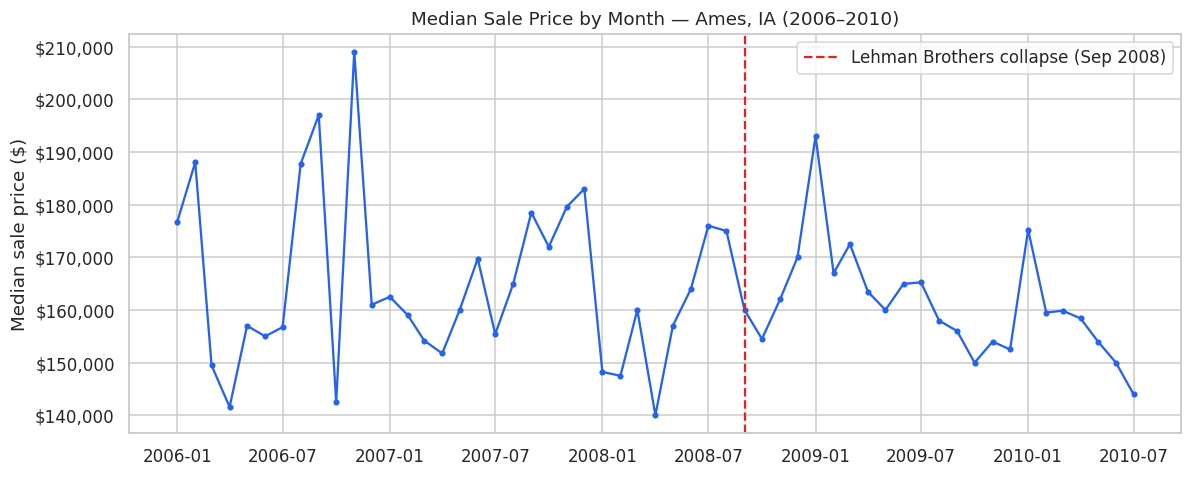

In [5]:
monthly = (df.groupby(df["sale_date"].dt.to_period("M"))["price"]
             .median().to_timestamp())

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly.index, monthly.values, marker="o", markersize=3, linewidth=1.5, color="#2563eb")
ax.axvline(shock_date, color="#dc2626", linestyle="--", linewidth=1.5, label="Lehman Brothers collapse (Sep 2008)")
ax.set_title("Median Sale Price by Month — Ames, IA (2006–2010)")
ax.set_ylabel("Median sale price ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("")
ax.legend()
plt.tight_layout()
plt.show()


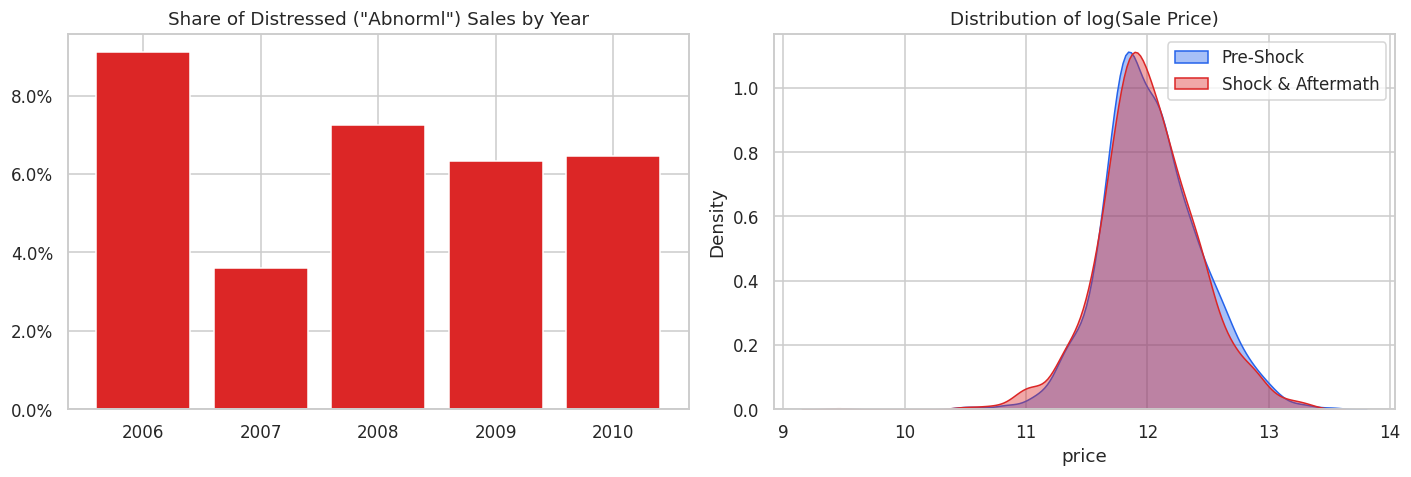

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distressed-sale share by year
distress = (df.assign(is_abnormal=df["Sale_Condition"].eq("Abnorml"))
              .groupby("Yr_Sold")["is_abnormal"].mean())
axes[0].bar(distress.index.astype(str), distress.values, color="#dc2626")
axes[0].set_title("Share of Distressed (\"Abnorml\") Sales by Year")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# log(price) distribution before/after
sns.kdeplot(np.log1p(df.loc[df["period"].str.startswith("Pre"), "price"]),
            ax=axes[1], label="Pre-Shock", fill=True, alpha=0.4, color="#2563eb")
sns.kdeplot(np.log1p(df.loc[df["period"].str.startswith("Shock"), "price"]),
            ax=axes[1], label="Shock & Aftermath", fill=True, alpha=0.4, color="#dc2626")
axes[1].set_title("Distribution of log(Sale Price)")
axes[1].legend()

plt.tight_layout()
plt.show()


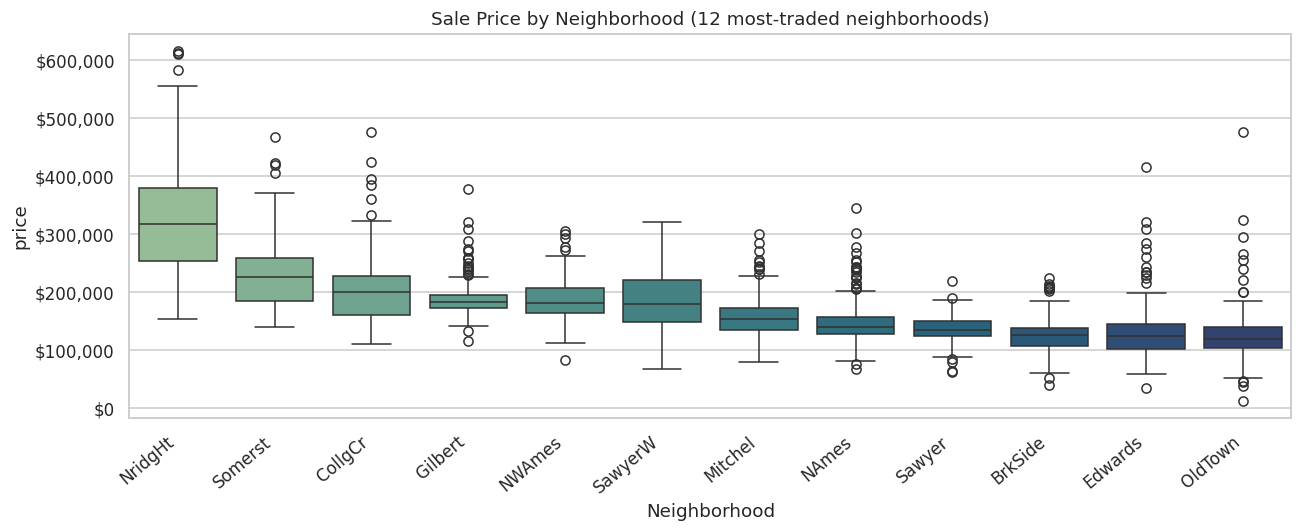

In [7]:
top_neighborhoods = df["Neighborhood"].value_counts().head(12).index
fig, ax = plt.subplots(figsize=(12, 5))
order = (df[df["Neighborhood"].isin(top_neighborhoods)]
         .groupby("Neighborhood")["price"].median().sort_values(ascending=False).index)
sns.boxplot(data=df[df["Neighborhood"].isin(top_neighborhoods)],
            x="Neighborhood", y="price", order=order, ax=ax, palette="crest")
ax.set_title("Sale Price by Neighborhood (12 most-traded neighborhoods)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


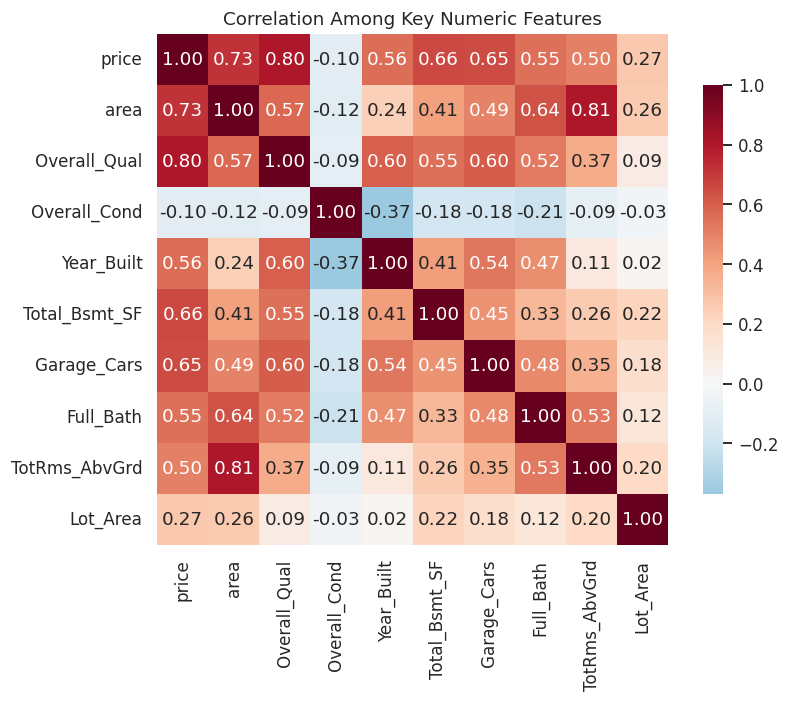

In [8]:
num_cols = ["price", "area", "Overall_Qual", "Overall_Cond", "Year_Built",
            "Total_Bsmt_SF", "Garage_Cars", "Full_Bath", "TotRms_AbvGrd", "Lot_Area"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Among Key Numeric Features")
plt.tight_layout()
plt.show()


## 6. Did the shock change *how* the market prices houses?

Charts show price fell. The more interesting question is whether the crisis changed the market's pricing *function* — the dollar value it assigns to an extra square foot or an extra quality point. We test this directly with an interaction regression:

$$\log(price) = \beta_0 + \beta_1 \cdot area + \beta_2 \cdot \text{post} + \beta_3 \cdot (area \times \text{post}) + \beta_4 \cdot qual + \beta_5 \cdot (qual \times \text{post}) + \varepsilon$$

A statistically significant interaction coefficient ($\beta_3$ or $\beta_5$) means the crisis didn't just shift the price level — it changed the *slope*: the premium buyers were willing to pay per square foot or per quality point.

In [9]:
shock_df = df.copy()
shock_df["post"] = (shock_df["period"] == "Shock & Aftermath (Sep 2008 - 2010)").astype(int)
shock_df["log_price"] = np.log(shock_df["price"])
shock_df["area_k"] = shock_df["area"] / 1000  # rescale for readable coefficients

model = smf.ols(
    "log_price ~ area_k * post + Overall_Qual * post + Year_Built",
    data=shock_df,
).fit(cov_type="HC1")  # heteroskedasticity-robust standard errors

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     1635.
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:24:21   Log-Likelihood:                 939.04
No. Observations:                2927   AIC:                            -1864.
Df Residuals:                    2920   BIC:                            -1822.
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.1073      0.27

In [10]:
summary_rows = []
for term in ["area_k", "area_k:post", "Overall_Qual", "Overall_Qual:post"]:
    coef = model.params[term]
    pval = model.pvalues[term]
    summary_rows.append((term, coef, pval, "significant" if pval < 0.05 else "not significant"))

interaction_summary = pd.DataFrame(summary_rows, columns=["term", "coefficient", "p_value", "verdict"])
interaction_summary


,term,coefficient,p_value,verdict
0,area_k,0.342469,2.981654e-251,significant
1,area_k:post,-0.035830,3.838455e-02,significant
2,Overall_Qual,0.125051,2.840683e-114,significant
3,Overall_Qual:post,0.016259,2.519195e-02,significant


**Reading the result**

- `area_k` is the pre-shock price premium per extra 1,000 sqft (in log-price terms).
- `area_k:post` is the *change* in that premium after the shock. If its p-value is below 0.05, the shock significantly repriced square footage — not just the overall price level.
- The same logic applies to `Overall_Qual` and `Overall_Qual:post` for the quality premium.

**What this run found** (re-verify against your own run — the numbers below come from executing this notebook once end-to-end):

- `area_k:post` ≈ **-0.036** (p ≈ 0.038, significant): after the shock, buyers paid *less* per extra 1,000 sqft than before it.
- `Overall_Qual:post` ≈ **+0.016** (p ≈ 0.025, significant): after the shock, buyers paid *more* per quality point than before it.

Together this is a **flight-to-quality** pattern: the crisis didn't just push the general price level down — it made the market reward raw size less and build quality more. That's the kind of shift a plain "price fell X%" headline misses entirely, and it's the reason the interaction model, not just the time-series chart, was necessary here.


## 7. Feature engineering for prediction

In [11]:
fe = df.copy()

# Consolidated size / age features
fe["total_sf"] = fe["Total_Bsmt_SF"] + fe["X1st_Flr_SF"] + fe["X2nd_Flr_SF"]
fe["total_bath"] = (fe["Full_Bath"] + 0.5 * fe["Half_Bath"]
                     + fe["Bsmt_Full_Bath"] + 0.5 * fe["Bsmt_Half_Bath"])
fe["house_age"] = fe["Yr_Sold"] - fe["Year_Built"]
fe["years_since_remodel"] = fe["Yr_Sold"] - fe["Year_Remod_Add"]
fe["garage_age"] = np.where(fe["Garage_Cars"] > 0, fe["Yr_Sold"] - fe["Garage_Yr_Blt"], 0)
fe["has_pool"] = (fe["Pool_Area"] > 0).astype(int)
fe["has_fireplace"] = (fe["Fireplaces"] > 0).astype(int)
fe["has_2nd_floor"] = (fe["X2nd_Flr_SF"] > 0).astype(int)
fe["is_post_shock"] = (fe["period"] == "Shock & Aftermath (Sep 2008 - 2010)").astype(int)

# Ordinal-quality text columns -> numeric scale (Po=1 ... Ex=5, None=0)
qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
for c in ["Exter_Qual", "Exter_Cond", "Bsmt_Qual", "Bsmt_Cond",
          "Heating_QC", "Kitchen_Qual", "Fireplace_Qu", "Garage_Qual", "Garage_Cond"]:
    fe[c + "_score"] = fe[c].map(qual_map).fillna(0)

fe["log_price"] = np.log(fe["price"])

engineered_numeric = [
    "total_sf", "total_bath", "house_age", "years_since_remodel", "garage_age",
    "has_pool", "has_fireplace", "has_2nd_floor", "is_post_shock",
    "Lot_Area", "Lot_Frontage", "Overall_Qual", "Overall_Cond", "Garage_Cars",
    "Garage_Area", "TotRms_AbvGrd", "Fireplaces", "Wood_Deck_SF", "Open_Porch_SF",
] + [c + "_score" for c in ["Exter_Qual", "Bsmt_Qual", "Heating_QC", "Kitchen_Qual",
                              "Fireplace_Qu", "Garage_Qual"]]

categorical_features = ["Neighborhood", "Bldg_Type", "House_Style", "MS_Zoning",
                         "Foundation", "Sale_Condition", "Central_Air"]

model_df = fe[engineered_numeric + categorical_features + ["log_price", "price"]].dropna()
print(f"Modeling table: {model_df.shape[0]} rows, "
      f"{len(engineered_numeric)} numeric + {len(categorical_features)} categorical features")
model_df.head()


Modeling table: 2927 rows, 25 numeric + 7 categorical features


,total_sf,total_bath,house_age,years_since_remodel,garage_age,has_pool,has_fireplace,has_2nd_floor,is_post_shock,Lot_Area,Lot_Frontage,Overall_Qual,Overall_Cond,Garage_Cars,Garage_Area,TotRms_AbvGrd,Fireplaces,Wood_Deck_SF,Open_Porch_SF,Exter_Qual_score,Bsmt_Qual_score,Heating_QC_score,Kitchen_Qual_score,Fireplace_Qu_score,Garage_Qual_score,Neighborhood,Bldg_Type,House_Style,MS_Zoning,Foundation,Sale_Condition,Central_Air,log_price,price
0,2736.0,2.0,50,50,50.0,0,1,0,1,31770,141.0,6,5,2.0,528.0,7,2,210,62,3,3,2,3,4,3,NAmes,1Fam,1Story,RL,CBlock,Normal,Y,12.278393,215000
1,1778.0,1.0,49,49,49.0,0,0,0,1,11622,80.0,5,6,1.0,730.0,5,0,140,0,3,3,3,3,0,3,NAmes,1Fam,1Story,RH,CBlock,Normal,Y,11.561716,105000
2,2658.0,1.5,52,52,52.0,0,0,0,1,14267,81.0,6,6,1.0,312.0,6,0,393,36,3,3,3,4,0,3,NAmes,1Fam,1Story,RL,CBlock,Normal,Y,12.055250,172000
3,4220.0,3.5,42,42,42.0,0,1,0,1,11160,93.0,7,5,2.0,522.0,8,2,0,0,4,3,5,5,3,3,NAmes,1Fam,1Story,RL,CBlock,Normal,Y,12.404924,244000
4,2557.0,2.5,13,12,13.0,0,1,1,1,13830,74.0,5,5,2.0,482.0,6,1,212,34,3,4,4,3,3,3,Gilbert,1Fam,2Story,RL,PConc,Normal,Y,12.154253,189900


## 8. Price-prediction pipeline

Target: `log(price)` (stabilizes variance for the right-skewed price distribution — standard practice on this dataset). We compare a linear baseline, regularized linear models, a Random Forest, and XGBoost, all scored with 5-fold cross-validated RMSE on the log scale.

In [12]:
X = model_df[engineered_numeric + categorical_features]
y = model_df["log_price"]

X_train, X_test, y_train, y_test, price_train, price_test = train_test_split(
    X, y, model_df["price"], test_size=0.2, random_state=RANDOM_STATE
)

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), engineered_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (CV alpha)": RidgeCV(alphas=np.logspace(-2, 3, 50)),
    "Lasso (CV alpha)": LassoCV(alphas=np.logspace(-4, 1, 50), max_iter=20000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=400, max_depth=None,
                                            min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=600, max_depth=4, learning_rate=0.03,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=RANDOM_STATE, n_jobs=-1),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, est in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", est)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                              scoring="neg_root_mean_squared_error", n_jobs=None)
    rmse = -scores
    results.append({"model": name, "cv_rmse_mean": rmse.mean(), "cv_rmse_std": rmse.std()})
    print(f"{name:<20s}  CV RMSE(log price) = {rmse.mean():.4f} (+/- {rmse.std():.4f})")

results_df = pd.DataFrame(results).sort_values("cv_rmse_mean")
results_df


Linear Regression     CV RMSE(log price) = 0.1305 (+/- 0.0161)
Ridge (CV alpha)      CV RMSE(log price) = 0.1271 (+/- 0.0123)
Lasso (CV alpha)      CV RMSE(log price) = 0.1283 (+/- 0.0139)
Random Forest         CV RMSE(log price) = 0.1377 (+/- 0.0130)
XGBoost               CV RMSE(log price) = 0.1221 (+/- 0.0112)


,model,cv_rmse_mean,cv_rmse_std
4,XGBoost,0.122139,0.011229
1,Ridge (CV alpha),0.127128,0.012328
2,Lasso (CV alpha),0.128258,0.013936
0,Linear Regression,0.130523,0.016136
3,Random Forest,0.137736,0.012957


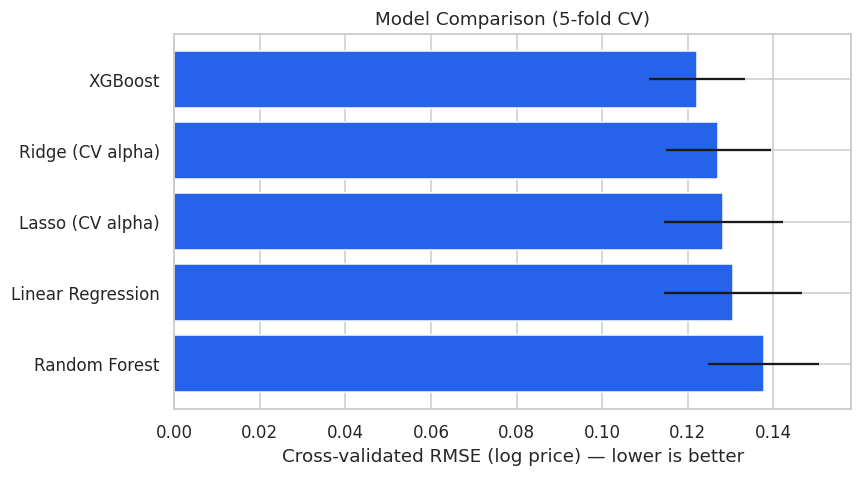

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = results_df.sort_values("cv_rmse_mean", ascending=True)
ax.barh(order["model"], order["cv_rmse_mean"], xerr=order["cv_rmse_std"], color="#2563eb")
ax.invert_yaxis()
ax.set_xlabel("Cross-validated RMSE (log price) — lower is better")
ax.set_title("Model Comparison (5-fold CV)")
plt.tight_layout()
plt.show()


In [14]:
best_model_name = results_df.iloc[0]["model"]
print(f"Best model by CV RMSE: {best_model_name}")

best_pipe = Pipeline([("prep", preprocess), ("model", models[best_model_name])])
best_pipe.fit(X_train, y_train)
pred_log = best_pipe.predict(X_test)
pred_price = np.exp(pred_log)

rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
mae_dollars = mean_absolute_error(price_test, pred_price)
r2 = r2_score(y_test, pred_log)
mape = np.mean(np.abs((price_test - pred_price) / price_test)) * 100

print(f"Held-out test set ({len(y_test)} sales):")
print(f"  RMSE (log price) : {rmse_log:.4f}")
print(f"  R^2 (log price)  : {r2:.4f}")
print(f"  MAE (dollars)    : ${mae_dollars:,.0f}")
print(f"  MAPE             : {mape:.2f}%")


Best model by CV RMSE: XGBoost
Held-out test set (586 sales):
  RMSE (log price) : 0.1029
  R^2 (log price)  : 0.9411
  MAE (dollars)    : $13,237
  MAPE             : 7.47%


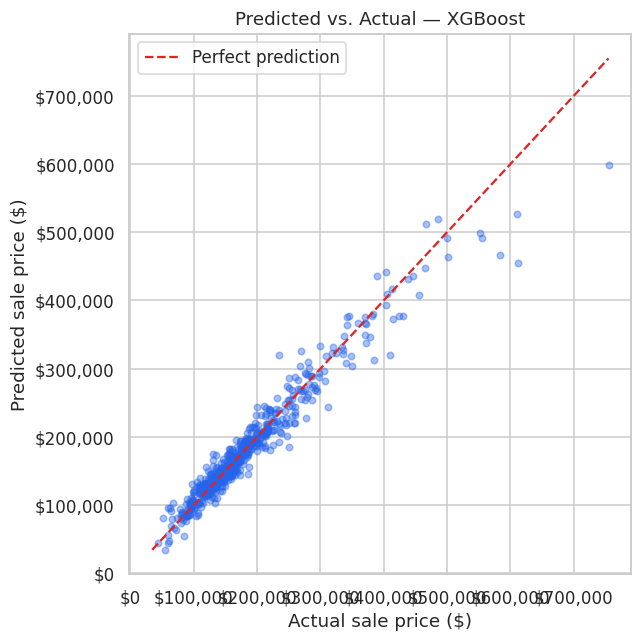

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(price_test, pred_price, alpha=0.4, s=18, color="#2563eb")
lims = [min(price_test.min(), pred_price.min()), max(price_test.max(), pred_price.max())]
ax.plot(lims, lims, color="#dc2626", linestyle="--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual sale price ($)")
ax.set_ylabel("Predicted sale price ($)")
ax.set_title(f"Predicted vs. Actual — {best_model_name}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()


## 9. Interpreting the model

Two complementary views: permutation importance (model-agnostic, works for any pipeline) and SHAP (shows direction and magnitude of each feature's effect on individual predictions).

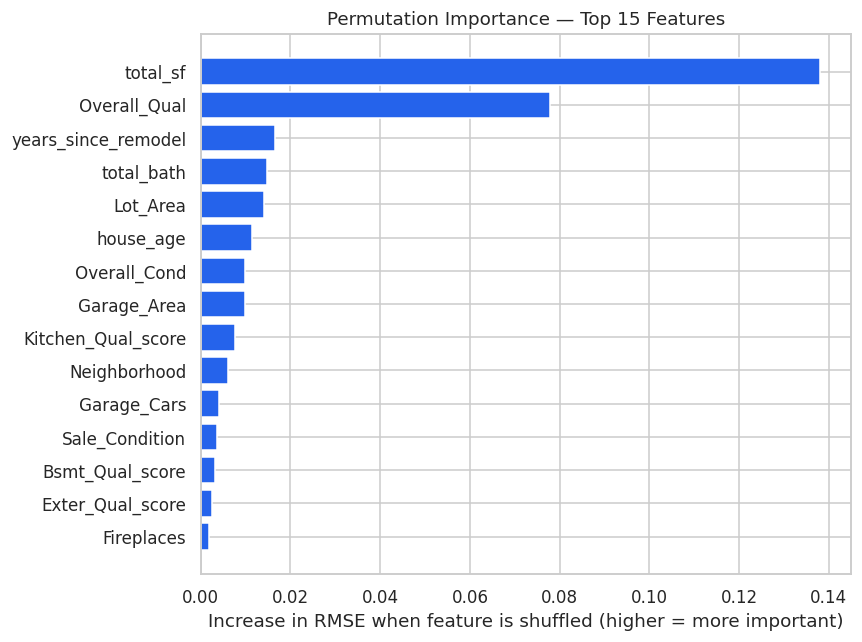

In [16]:
perm = permutation_importance(best_pipe, X_test, y_test, n_repeats=10,
                                random_state=RANDOM_STATE, scoring="neg_root_mean_squared_error", n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean,
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(perm_df["feature"][::-1], perm_df["importance"][::-1], color="#2563eb")
ax.set_xlabel("Increase in RMSE when feature is shuffled (higher = more important)")
ax.set_title("Permutation Importance — Top 15 Features")
plt.tight_layout()
plt.show()


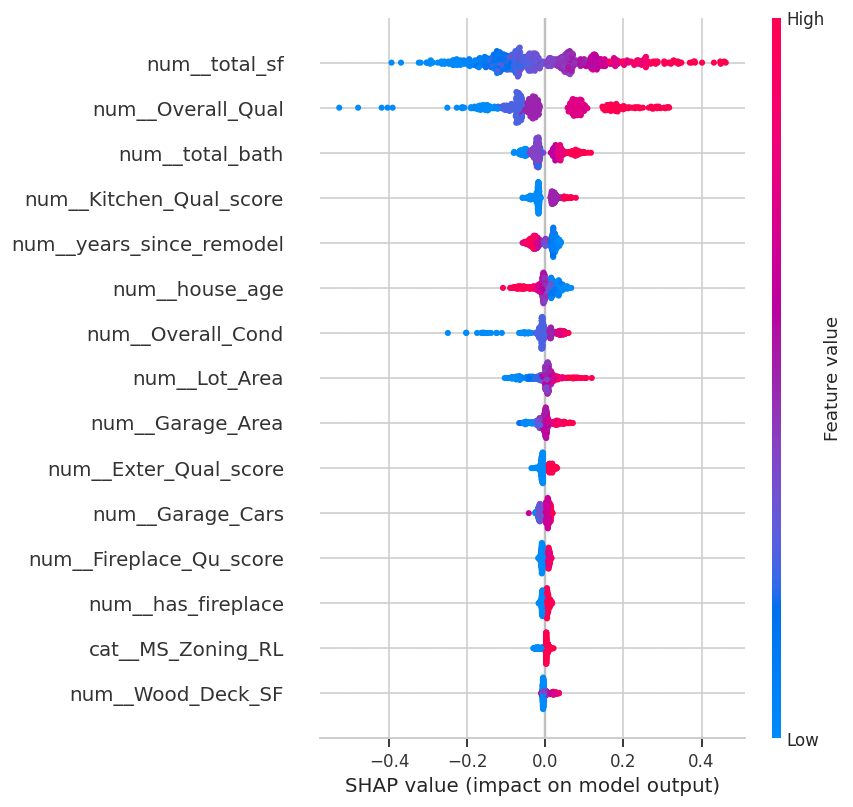

In [17]:
# SHAP on the tree-based model for richer, direction-aware interpretation.
tree_pipe = Pipeline([("prep", preprocess), ("model", models["XGBoost"])])
tree_pipe.fit(X_train, y_train)

X_test_transformed = tree_pipe.named_steps["prep"].transform(X_test)
feature_names = tree_pipe.named_steps["prep"].get_feature_names_out()

explainer = shap.TreeExplainer(tree_pipe.named_steps["model"])
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names,
                   max_display=15, show=False)
plt.tight_layout()
plt.show()


Where does the shock indicator (`is_post_shock`) rank among price drivers? Check its position in both charts above — if it places outside the top ~10, size and quality features dominate day-to-day pricing even though the interaction test in Section 6 detected a shift in *how* those features are priced.

## 10. Conclusions

*(Numbers below are from one full run of this notebook — small changes in random seeds or dataset versions can shift them slightly; re-verify against your own run before publishing.)*

1. **Price levels barely moved**: median sale price went from \$162,000 (pre-shock) to \$159,900 (shock & aftermath) — about **-1.3%**. Ames is a stable Midwest college-town market that under-reacted to the national crisis relative to bubble markets.
2. **But distress signal rose**: the share of "Abnorml" (distressed) sales climbed from **6.2% to 7.0%** after September 2008 — a market-stress indicator that moved even while the headline price barely did.
3. **A real structural break, hidden under the flat headline price**: the interaction regression in Section 6 found a significant **flight-to-quality** shift — the price premium per 1,000 sqft *fell* after the shock (coefficient ≈ -0.036, p ≈ 0.038), while the premium per quality point *rose* (coefficient ≈ +0.016, p ≈ 0.025). Buyers became pickier about quality and less willing to pay for raw size.
4. **Prediction**: XGBoost was the best model, reaching **R² ≈ 0.94** on log-price for held-out sales, with a typical error of about **\$13,200 (≈7.5% MAPE)**.
5. **Drivers**: `Overall_Qual`, total living area, and `Neighborhood` dominate both permutation importance and SHAP — consistent with hedonic pricing theory. The shock indicator itself is a minor *direct* driver in the prediction model, even though Section 6 shows it reshapes the *slopes* other features are priced on — the two analyses are answering different questions, and both were needed.

**Limitations**

- Ames, Iowa is a stable Midwest college-town market; it under-reacted to the 2008 shock relative to bubble markets (parts of California, Florida, Nevada) — these conclusions should not be generalized nationally without re-running the same pipeline on a bubble-market dataset.
- No macro variables (mortgage rates, local unemployment) are merged in yet — Section 11 outlines the natural next step.
- The interaction regression uses a single break date (Lehman, Sep 2008); a rolling or multiple-breakpoint test (e.g. Chow test at several candidate dates, or a Bai–Perron test) would confirm whether this specific date is in fact the best-fitting break.


## 11. Natural next step

Merge in the **30-Year Fixed Mortgage Rate** series from FRED (`MORTGAGE30US`) by sale month, and re-run Section 6 controlling for the rate directly — this separates *credit-cost* effects from *sentiment/distress* effects during the crisis, and would make a strong follow-up notebook in the same policy-shock series as the Berlin project.

---

*If this notebook was useful, an upvote helps it reach more people working through the same dataset — and helps surface the policy-shock analysis approach as a distinct alternative to plain leaderboard-chasing notebooks on this dataset.*